# Predicting soil moisture with LSTM and GRU networks

**What this notebook answers:** can a neural network predict how wet the soil
is, and is it better than the obvious simple answers?

The models here are trained in PyTorch on the thirty-year NASA record. The
target is real, published, independently produced soil moisture - not anything
this project generated - so the scores below cannot be inflated by a model
learning its own simulator's assumptions.

## Two different questions

These get confused constantly, and conflating them is how soil-moisture models
come to look far better than they are.

**Question A - forecasting.** *Given everything up to today, including how wet
the soil is now, how wet will it be tomorrow?* This is easy, because soil
moisture changes slowly. The honest benchmark is "assume tomorrow is the same
as today" - the **persistence** baseline.

**Question B - estimation.** *Given only the weather, how wet is the soil?* No
moisture readings at any point. This is much harder, and much closer to the
real situation: a site with no sensor, or one whose sensor has drifted. The
benchmark is **climatology** - "whatever is normal for this date".

Reporting only Question A would be flattering and close to meaningless. Both
are run.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from irrigation.viz import apply_style, colour_for, dashes_for, marker_for, ACTUAL

apply_style()

from irrigation.data.nasa_power import load_records
from irrigation.models import sequence as S

records = load_records()

configs = {
    ("forecast", "lstm"): S.SequenceConfig(task="forecast", cell="lstm"),
    ("forecast", "gru"): S.SequenceConfig(task="forecast", cell="gru"),
    ("estimate", "lstm"): S.SequenceConfig(task="estimate", cell="lstm"),
    ("estimate", "gru"): S.SequenceConfig(task="estimate", cell="gru"),
}

datasets = {
    task: S.build_dataset(records, S.SequenceConfig(task=task))
    for task in ("forecast", "estimate")
}

for task, dataset in datasets.items():
    print(f"{task.upper():9s} train {dataset.x_train.shape[0]:>5,}  "
          f"val {dataset.x_val.shape[0]:>5,}  test {dataset.x_test.shape[0]:>5,}  "
          f"features {len(dataset.feature_names)}")
print()
print("Forecast inputs:", ", ".join(datasets["forecast"].feature_names))
print("Estimate inputs:", ", ".join(datasets["estimate"].feature_names))


FORECAST  train 8,015  val 1,461  test 1,461  features 11
ESTIMATE  train 8,015  val 1,461  test 1,461  features 9

Forecast inputs: tmax_c, tmin_c, dewpoint_c, solar_mj, wind_2m_ms, rainfall_mm, et0_mm, doy_sin, doy_cos, wetness_root, wetness_top
Estimate inputs: tmax_c, tmin_c, dewpoint_c, solar_mj, wind_2m_ms, rainfall_mm, et0_mm, doy_sin, doy_cos


## Splitting the data honestly

The single most common way to get a spectacular and worthless soil moisture
result is to shuffle the data before splitting it. Soil moisture changes over
weeks, so if Tuesday is in the training set and Wednesday is in the test set,
the model is effectively being shown the answer.

The split here is **chronological**: train on the earliest years, tune on the
middle years, and touch the final four years exactly once, at the end.


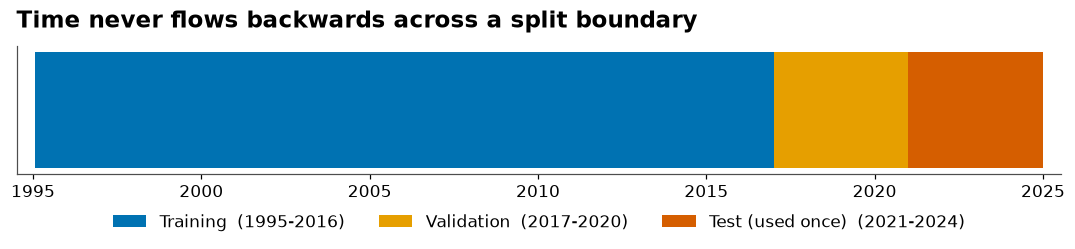

In [2]:
dataset = datasets["forecast"]
fig, ax = plt.subplots(figsize=(10, 2.6))

spans = [
    ("Training", dataset.dates_train, "#0072B2"),
    ("Validation", dataset.dates_val, "#E69F00"),
    ("Test (used once)", dataset.dates_test, "#D55E00"),
]
for index, (label, dates, colour) in enumerate(spans):
    ax.barh(0, (max(dates) - min(dates)).days, left=min(dates).toordinal(),
            height=0.5, color=colour, label=f"{label}  ({min(dates).year}-{max(dates).year})")

ax.set_yticks([])
ax.set_xlim(min(dataset.dates_train).toordinal() - 200,
            max(dataset.dates_test).toordinal() + 200)
ticks = [np.datetime64(f"{y}-01-01").astype("datetime64[D]").astype(int) + 719163
         for y in range(1995, 2026, 5)]
ax.set_xticks(ticks, [str(y) for y in range(1995, 2026, 5)])
ax.set_title("Time never flows backwards across a split boundary")
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.2))
ax.grid(False)

plt.tight_layout()
plt.show()


In [3]:
results = {}
for (task, cell), config in configs.items():
    results[(task, cell)] = S.train_sequence_model(datasets[task], config)
    metrics = results[(task, cell)].metrics
    print(f"{task:9s} {cell.upper():5s} "
          f"RMSE {metrics['rmse']:.5f}  MAE {metrics['mae']:.5f}  "
          f"R2 {metrics['r2']:.4f}  (best epoch {results[(task, cell)].best_epoch})")

baselines = {
    ("forecast", "Persistence"): S.persistence_baseline(datasets["forecast"],
                                                        configs[("forecast", "lstm")]),
    ("forecast", "Climatology"): S.climatology_baseline(records, datasets["forecast"],
                                                        configs[("forecast", "lstm")]),
    ("estimate", "Climatology"): S.climatology_baseline(records, datasets["estimate"],
                                                        configs[("estimate", "lstm")]),
}
print()
for (task, name), predictions in baselines.items():
    metrics = S.regression_metrics(datasets[task].y_test, predictions)
    print(f"{task:9s} {name:12s} RMSE {metrics['rmse']:.5f}  "
          f"MAE {metrics['mae']:.5f}  R2 {metrics['r2']:.4f}")


forecast  LSTM  RMSE 0.00467  MAE 0.00256  R2 0.9853  (best epoch 15)
forecast  GRU   RMSE 0.00493  MAE 0.00267  R2 0.9836  (best epoch 13)
estimate  LSTM  RMSE 0.02022  MAE 0.01432  R2 0.7243  (best epoch 6)
estimate  GRU   RMSE 0.02147  MAE 0.01525  R2 0.6891  (best epoch 11)

forecast  Persistence  RMSE 0.00580  MAE 0.00142  R2 0.9773
forecast  Climatology  RMSE 0.03498  MAE 0.02316  R2 0.1752
estimate  Climatology  RMSE 0.03498  MAE 0.02316  R2 0.1752


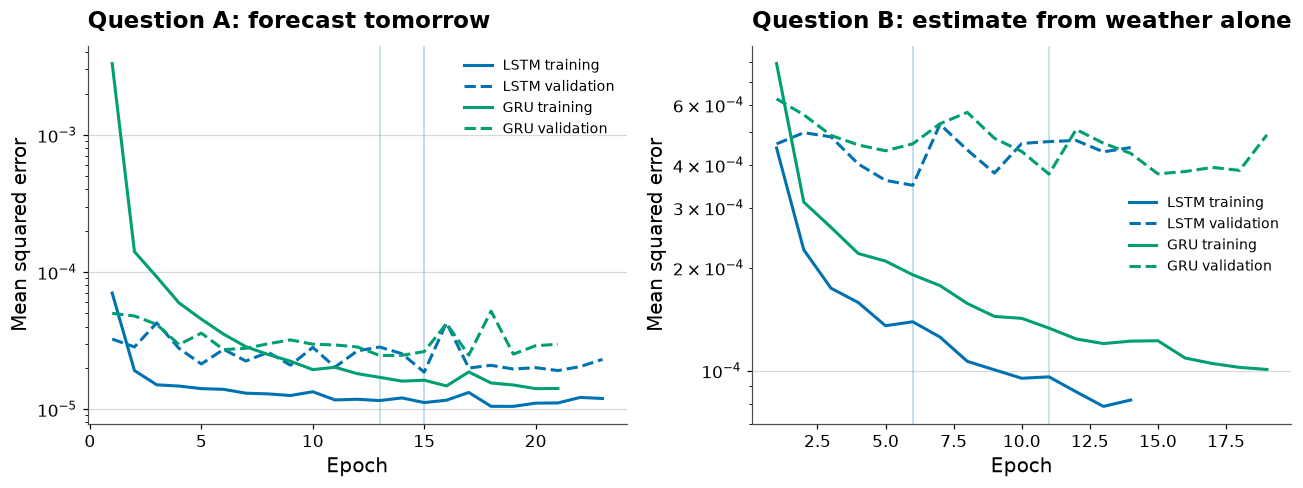

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)

for ax, (task, title) in zip(axes, [("forecast", "Question A: forecast tomorrow"),
                                    ("estimate", "Question B: estimate from weather alone")]):
    for cell in ("lstm", "gru"):
        result = results[(task, cell)]
        ax.plot(range(1, len(result.train_losses) + 1), result.train_losses,
                color=colour_for(cell.upper()), label=f"{cell.upper()} training")
        ax.plot(range(1, len(result.val_losses) + 1), result.val_losses,
                color=colour_for(cell.upper()), linestyle="--",
                label=f"{cell.upper()} validation")
        ax.axvline(result.best_epoch, color=colour_for(cell.upper()),
                   alpha=0.3, linewidth=1)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean squared error")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## The result, and the catch

The vertical lines mark where each model was at its best on the validation
years. Training stopped shortly after and the best weights were restored, so
the test scores below come from the model that generalized best rather than
the one that trained longest.

Now the interesting part.


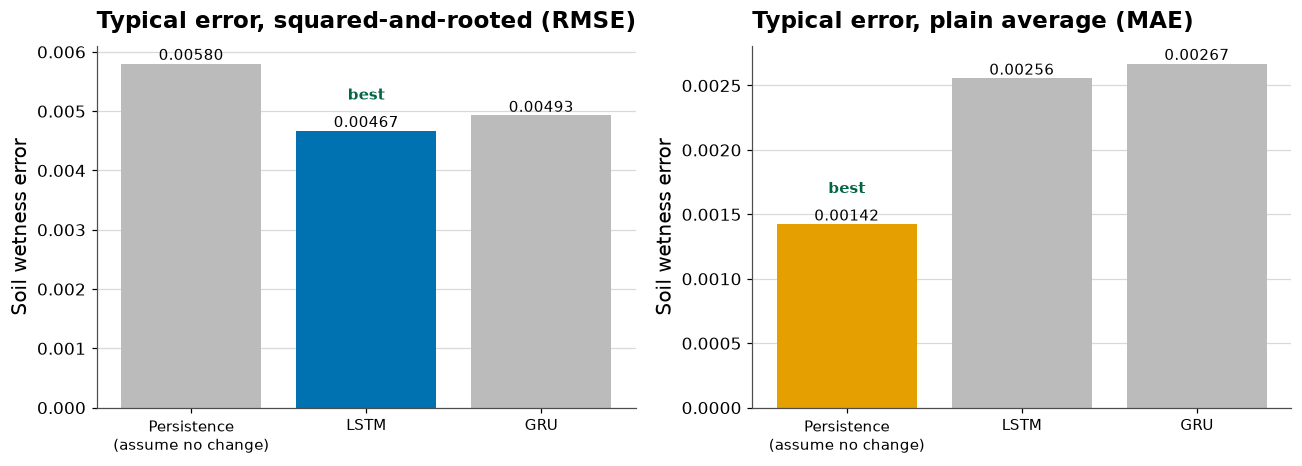

In [5]:
rows = [
    ("Persistence\n(assume no change)", "forecast", baselines[("forecast", "Persistence")]),
    ("LSTM", "forecast", results[("forecast", "lstm")].predictions_test),
    ("GRU", "forecast", results[("forecast", "gru")].predictions_test),
]
names = [r[0] for r in rows]
metrics = [S.regression_metrics(datasets[r[1]].y_test, r[2]) for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
positions = np.arange(len(rows))
palette = ["#E69F00", "#0072B2", "#009E73"]

for ax, key, title in [(axes[0], "rmse", "Typical error, squared-and-rooted (RMSE)"),
                       (axes[1], "mae", "Typical error, plain average (MAE)")]:
    values = [m[key] for m in metrics]
    best = int(np.argmin(values))
    bars = ax.bar(positions, values,
                  color=[palette[i] if i == best else "#BBBBBB" for i in range(len(values))])
    ax.set_xticks(positions, names, fontsize=10)
    ax.set_ylabel("Soil wetness error")
    ax.set_title(title)
    for index, value in enumerate(values):
        ax.annotate(f"{value:.5f}", (index, value), ha="center", va="bottom", fontsize=10)
    ax.annotate("best", (best, values[best]), ha="center", va="bottom",
                fontsize=10, fontweight="bold", xytext=(0, 18),
                textcoords="offset points", color="#006644")

plt.tight_layout()
plt.show()


## The winner depends on the question you ask

**The LSTM has the lower RMSE. Persistence has the lower MAE.** Same models,
same data, same test years - opposite conclusions.

This is not a paradox and not a bug. It is what the two measures mean.

- **MAE** is the average error. Persistence wins because on most days in a
  desert nothing happens, and "the same as yesterday" is then exactly right.
- **RMSE** squares errors before averaging, so a few large misses dominate.
  Persistence is badly wrong on the handful of days when it rains and the soil
  jumps. The LSTM is slightly wrong every day but handles those jumps.

So: **persistence is better on a normal day. The network is better on the days
that matter.** Which one is "accurate" depends entirely on whether being wrong
occasionally-and-badly costs more than being wrong constantly-and-slightly.

That question cannot be answered by a metric. It is answered by what the error
costs in the field - which is the subject of the next notebook, and the central
argument of this project.


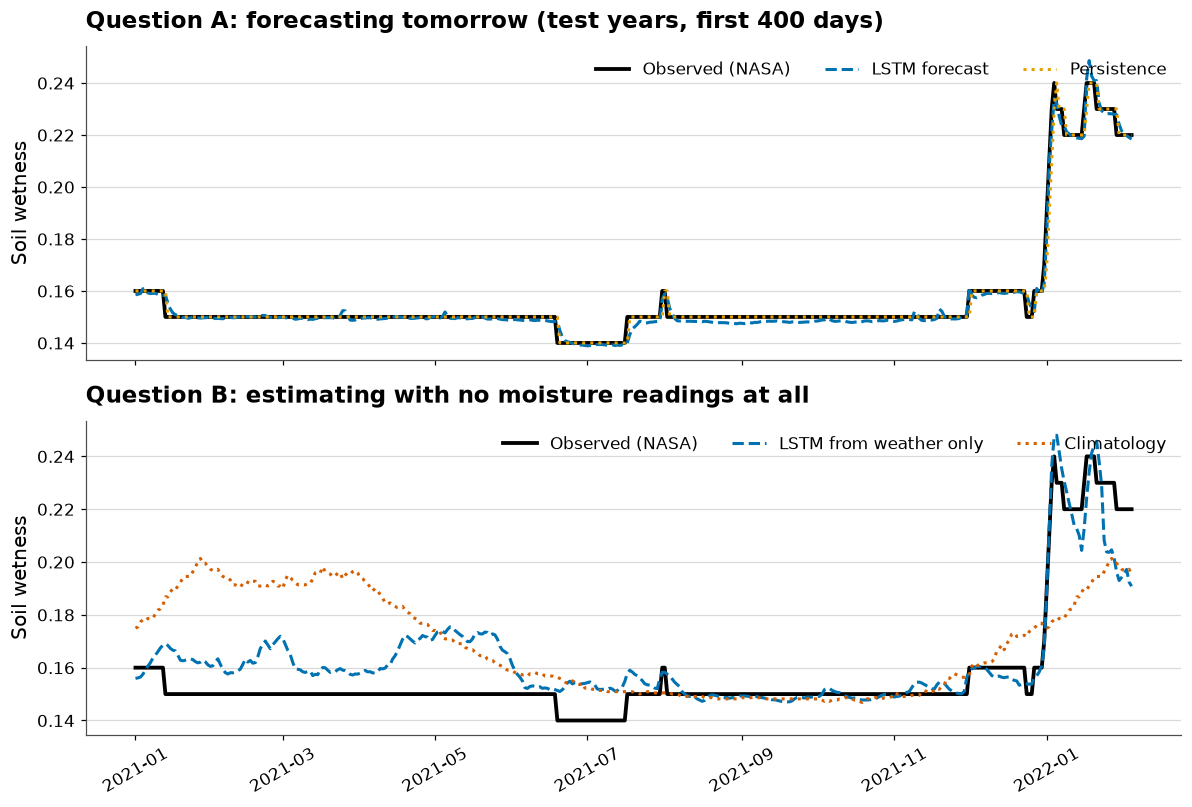

In [6]:
dataset = datasets["forecast"]
window = slice(0, 400)
dates = dataset.dates_test[window]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

axes[0].plot(dates, dataset.y_test[window], color=ACTUAL, linewidth=2.5,
             label="Observed (NASA)")
axes[0].plot(dates, results[("forecast", "lstm")].predictions_test[window],
             color="#0072B2", linestyle="--", label="LSTM forecast")
axes[0].plot(dates, baselines[("forecast", "Persistence")][window],
             color="#E69F00", linestyle=":", label="Persistence")
axes[0].set_ylabel("Soil wetness")
axes[0].set_title("Question A: forecasting tomorrow (test years, first 400 days)")
axes[0].legend(ncol=3, loc="upper right")

estimate_dataset = datasets["estimate"]
axes[1].plot(estimate_dataset.dates_test[window], estimate_dataset.y_test[window],
             color=ACTUAL, linewidth=2.5, label="Observed (NASA)")
axes[1].plot(estimate_dataset.dates_test[window],
             results[("estimate", "lstm")].predictions_test[window],
             color="#0072B2", linestyle="--", label="LSTM from weather only")
axes[1].plot(estimate_dataset.dates_test[window],
             baselines[("estimate", "Climatology")][window],
             color="#D55E00", linestyle=":", label="Climatology")
axes[1].set_ylabel("Soil wetness")
axes[1].set_title("Question B: estimating with no moisture readings at all")
axes[1].legend(ncol=3, loc="upper right")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


The two panels show why the distinction matters so much.

**Top:** with yesterday's reading available, both methods track the truth
closely. The curves are nearly indistinguishable at this scale.

**Bottom:** with only weather available, the LSTM captures the seasonal drying
and the broad response to rain, but misses the sharp spikes. It is far better
than the seasonal average - but visibly not the same as measuring.

The gap between the panels is the honest value of a working soil moisture
sensor. It is large.


In [7]:
summary = []
for task in ("forecast", "estimate"):
    for name, predictions in [
        ("LSTM", results[(task, "lstm")].predictions_test),
        ("GRU", results[(task, "gru")].predictions_test),
    ]:
        summary.append((task, name, S.regression_metrics(datasets[task].y_test, predictions)))
for (task, name), predictions in baselines.items():
    summary.append((task, name, S.regression_metrics(datasets[task].y_test, predictions)))

header = f"{'Question':<10} {'Method':<14} {'RMSE':>9} {'MAE':>9} {'R2':>8}"
print(header)
print("-" * len(header))
for task, name, metrics in sorted(summary, key=lambda row: (row[0], row[2]["rmse"])):
    print(f"{task:<10} {name:<14} {metrics['rmse']:>9.5f} "
          f"{metrics['mae']:>9.5f} {metrics['r2']:>8.4f}")


Question   Method              RMSE       MAE       R2
------------------------------------------------------
estimate   LSTM             0.02022   0.01432   0.7243
estimate   GRU              0.02147   0.01525   0.6891
estimate   Climatology      0.03498   0.02316   0.1752
forecast   LSTM             0.00467   0.00256   0.9853
forecast   GRU              0.00493   0.00267   0.9836
forecast   Persistence      0.00580   0.00142   0.9773
forecast   Climatology      0.03498   0.02316   0.1752


---

## Summary

| Finding | Detail |
|---|---|
| Networks beat persistence on RMSE | LSTM about 20% lower, driven by rain-response days |
| Persistence beats networks on MAE | It is exactly right on the many days nothing happens |
| Weather alone explains most of it | R2 around 0.72 with no moisture readings at all |
| A sensor is worth more than a model | Forecast error is roughly 4x smaller than estimate error |
| LSTM and GRU are equivalent here | Difference between them is smaller than the seed-to-seed spread |

**The honest conclusion:** the network adds real value, but a working sensor
adds much more, and the choice of accuracy metric decides the winner. That last
point is the one to carry into the next notebook.

Next: [03 - Irrigation decisions and what errors cost](03_irrigation_decisions_and_cost.ipynb)
